In [1]:
import numpy as np
from scipy.stats import skewnorm, lognorm
import matplotlib.pyplot as plt

In [2]:
statistics = {'a': 2.542562886886376,
  'loc': -1.114525560819975,
  'scale': 1.4973819434202296,
  'CV': 0.41696167189340216,
#   'n': 33539,
             }

In [3]:
def get_std_from_mean(mean_depth, grad):
    std = mean_depth * grad
    return (std)

def depth_distribution_from_depth(mean_depth, dep_bin_edges, statistics):
    dep_bin_centres = dep_bin_edges[:-1] + (dep_bin_edges[1] - dep_bin_edges[0]) / 2

    std = get_std_from_mean(mean_depth, statistics['CV'])

    std_bin_edges = (dep_bin_edges - mean_depth) / std
    std_bin_centres = std_bin_edges[:-1] + (std_bin_edges[1] - std_bin_edges[0]) / 2
    std_bw = np.nanmean(np.diff(std_bin_edges))

    fit = skewnorm.pdf(std_bin_centres,
                       statistics['a'],
                       statistics['loc'],
                       statistics['scale']) * std_bw

    return (dep_bin_centres, fit)

In [4]:
bin_width = 0.002
bin_edges = np.arange(0,2,bin_width)

### min SD 

0.28500000000000003
0.17300000000000001
0.093


Text(0.5, 0, 'Snow Depth (m)')

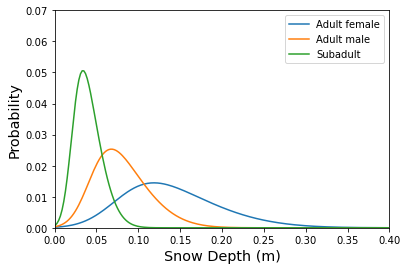

In [5]:
mean_depths = [0.14,0.08,0.04]
labels = ['Adult female','Adult male','Subadult']

for mean_depth,label in zip(mean_depths,labels):
    depth_bins, probability = depth_distribution_from_depth(mean_depth=mean_depth,dep_bin_edges=bin_edges,statistics=statistics)
    plt.plot(depth_bins,probability,label=label)
    print(np.nanmax(depth_bins[probability>0.001]))
plt.xlim(0,0.4)
plt.ylim(0,0.07)
plt.legend()
plt.ylabel('Probability', fontsize='x-large')
plt.xlabel('Snow Depth (m)', fontsize='x-large')

### find 10% 50 cm seal dens

In [6]:
mean_depth = 0.32

In [7]:
depth_bins, probability = depth_distribution_from_depth(mean_depth=mean_depth,dep_bin_edges=bin_edges,statistics=statistics)

Text(0.5, 0, 'Snow Depth (m)')

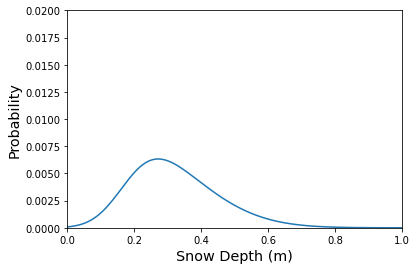

In [10]:
plt.plot(depth_bins,probability)
plt.xlim(0,1.0)
plt.ylim(0,0.02)
plt.ylabel('Probability', fontsize='x-large')
plt.xlabel('Snow Depth (m)', fontsize='x-large')

In [9]:
np.sum(probability[depth_bins>0.5])

0.09991624609919766